In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)

from src.utils import configure_logger

import pandas as pd

from typing import Any
from qqe.src.GNN.training.utils import collect_dataset_paths
from qqe.src.GNN.training.runners import MODEL_REGISTRY
from qqe.src.GNN.training.train_config import TrainConfig

from collections.abc import Callable
Loader = Callable[..., Any]

In [54]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

# Regime distributions

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from qqe.src.experiments.plotting import _plot_SRE_distribution
from qqe.src.GNN.dataset_builder import (
    DataGenConfig,
    RegimeDistribution,
    SamplingConfig,
    run_dataset_pipeline,
)
PROJECT_ROOT = Path().resolve().parent

In [80]:
n_qubits = (4, 6, 8, 10)
n_layers = (1, 2, 4, 8, 16, 40, 50, 80, 100)
n_seeds = 25
output_dir = "../outputs/data/SRE_distributions/test_4"

In [81]:
def default_sampling_config() -> SamplingConfig:
    return SamplingConfig(
        clifford=RegimeDistribution(
            regimes=["zero", "low", "medium", "high"],
            probabilities=[0.10, 0.10, 0.30, 0.50],
        ),
        random=RegimeDistribution(
            regimes=["identity_like", "clifford_like", "small_angles", "generic"],
            probabilities=[0.25, 0.25, 0.25, 0.25],
        ),
        quansistor=RegimeDistribution(
            regimes=[
                "identity_like",
                "weak",
                "moderate",
                "structured_equal_ab",
                "structured_opposite_ab",
                "generic_uniform",
            ],
            probabilities=[0.2, 0.15, 0.15, 0.15, 0.15, 0.2],
        ),
        haar=RegimeDistribution(
            regimes=["none", "sparse_weak", "dense_weak", "sparse_full", "medium", "full"],
            probabilities=[0.1, 0.15, 0.15, 0.15, 0.15, 0.3],
        ),
    )

In [53]:
def plot_SRE_regime(output_dir: str, family: str):
    rows = []

    for path in Path(output_dir+"/"+family).rglob("*.pt"):
        d = torch.load(path, map_location="cpu")

        meta = d["meta"]
        controls = meta.get("sampling_controls", {})
        realized = meta.get("realized_stats", {})

        row = {
            "path": str(path),
            "family": meta["family"],
            "regime": meta["regime"],
            "n_qubits": meta["n_qubits"],
            "n_layers": meta["n_layers"],
            "seed": meta["seed"],
            "sre": float(d.get("sre", np.nan)),
            "sre_density": float(d.get("sre", np.nan)) / meta["n_qubits"],
        }

        row.update({f"ctrl_{k}": v for k, v in controls.items()})
        row.update({f"real_{k}": v for k, v in realized.items()})

        rows.append(row)

    df = pd.DataFrame(rows)

    for family in df["family"].unique():
        sub = df[(df["family"] == family) & np.isfinite(df["sre_density"])]

        plt.figure()
        sub.boxplot(column="sre_density", by="regime", rot=45)
        plt.title(f"{family}: SRE density by regime")
        plt.suptitle("")
        plt.ylabel("SRE / n_qubits")
        plt.tight_layout()
        plt.show()

In [55]:
def make_dataset_loaders(
    model_type: str,
    epochs: int,
    lr: float,
    loss_type: str,
    batch_size: int,
    training_mode: str,
    family: str,
    target: str,
    data_dir: str,
    model_save_path: str,
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 10,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 600.0,
):
    cfg = TrainConfig(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        show_progress=show_progress,
        show_val_progress=show_val_progress,
        log_batch_loss_every=log_every_n_batches,
        heartbeat=heartbeat_secs,
        epoch_warning=epoch_time_warning_secs,
    )

    train_paths = collect_dataset_paths(
        data_dir,
        family=family if training_mode == "per_family" else None,
        split="target",
    )
    if not train_paths:
        raise RuntimeError("No data paths found.")
    logger.info(f"Found {len(train_paths)} data paths.")
    logger.info("Data paths collected.")

    spec = MODEL_REGISTRY[model_type]
    logger.info(f"Building loaders and model for model_type={model_type}...")

    loader_fn: Loader = spec["build_loaders"]
    returns_nodes_dim: bool = spec.get("returns_nodes_dim", False)
    if returns_nodes_dim:
        train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
    else:
        train_loader, val_loader, test_loader, global_in_dim, base_dataset = loader_fn(
            train_paths,
            batch_size=cfg.batch_size,
            seed=cfg.seed,
            train_split=cfg.train_split,
            val_split=cfg.val_split,
            global_feature_variant=cfg.global_feature_variant,
            node_feature_variant=cfg.node_feature_backend_variant,
            family_projection=family,
        )
        node_in_dim = global_in_dim

    return train_loader, val_loader, test_loader, node_in_dim, global_in_dim, base_dataset

## Clifford

### Dataset creation

In [82]:
cliff_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["clifford"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=50,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

In [83]:
run_dataset_pipeline(
    config=cliff_config,
    families=["clifford"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=cliff_config.n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

2026-05-21 14:07:20,158 - qqe.src.GNN.dataset_builder - INFO - Processing family: clifford
2026-05-21 14:07:20,163 - qqe.src.GNN.dataset_builder - INFO - Generated 1800 configs for clifford
2026-05-21 14:07:20,163 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-21 14:07:21,244 - qqe.src.parallel.dask - INFO - Dask client created successfully.
2026-05-21 14:07:21,246 - qqe.src.parallel.dask - INFO - Client dashboard available at: http://127.0.0.1:8787/status
Parallel dataset generation: 100%|██████████| 1800/1800 [02:05<00:00, 14.36it/s]
2026-05-21 14:09:27,964 - qqe.src.parallel.dask - INFO - Dask client and cluster closed.
2026-05-21 14:09:27,966 - qqe.src.GNN.dataset_builder - INFO - Completed clifford: 1199 entries
2026-05-21 14:09:27,967 - qqe.src.GNN.dataset_builder - INFO - Metadata: ..\outputs\data\SRE_distributions\test_4\clifford\metadata_clifford.json
2026-05-21 14:09:27,967 - qqe.src.GNN.dataset_builder - INFO - Samp

### Visualization

<Figure size 640x480 with 0 Axes>

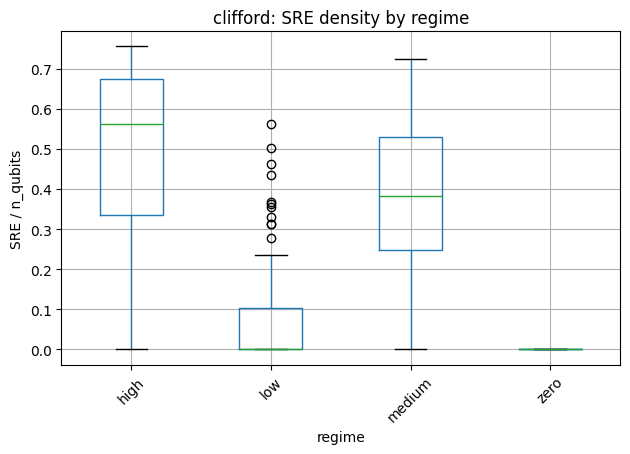

In [84]:
plot_SRE_regime(output_dir, "clifford")

<Figure size 640x480 with 0 Axes>

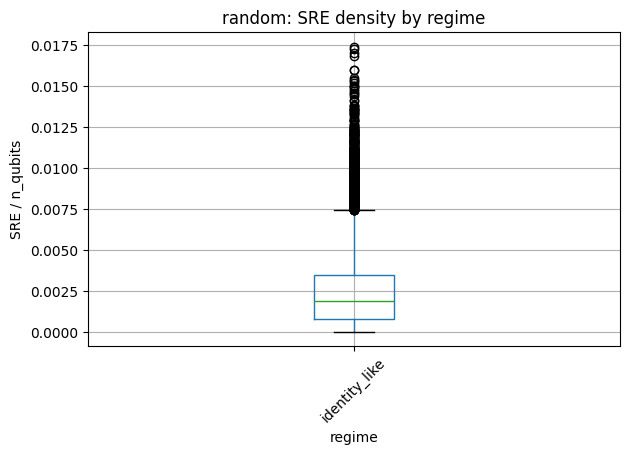

In [90]:
plot_SRE_regime("../outputs/data/identity_dataset", "random")

In [71]:
model_type="nn"
epochs = 30
lr = 1e-4
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "clifford"  # required if training_mode == "per_family"
target = "sre"
# data_dir = "../outputs/data/dataset"
model_save_path = "../outputs/models/clifford_model_gnn.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0

In [85]:
train_loader_clifford, val_loader_clifford, test_loader_clifford, node_in_dim_clifford, global_in_dim_clifford, base_dataset_clifford = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "clifford", target, output_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-21 14:09:54,926 - __main__ - INFO - Found 905 data paths.
2026-05-21 14:09:54,927 - __main__ - INFO - Data paths collected.
2026-05-21 14:09:54,927 - __main__ - INFO - Building loaders and model for model_type=nn...


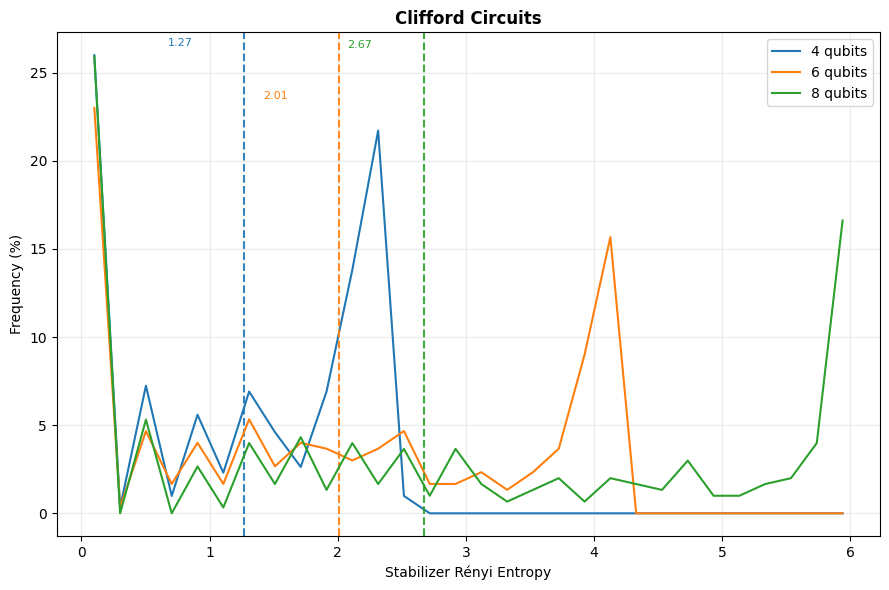

In [86]:
_plot_SRE_distribution(base_dataset_clifford, title="Clifford Circuits")

## Haar

In [87]:
output_dir = "../outputs/data/SRE_distributions/test_2"

In [42]:
haar_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["haar"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

In [43]:
run_dataset_pipeline(
    config=haar_config,
    families=["haar"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

Parallel dataset generation: 100%|██████████| 900/900 [01:08<00:00, 13.20it/s]


<Figure size 640x480 with 0 Axes>

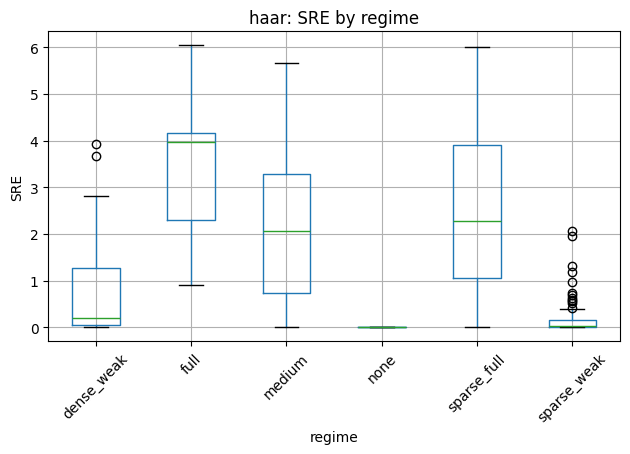

In [ ]:
plot_SRE_regime(output_dir, "haar")

## Random rotations

In [91]:
rot_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["random"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

In [92]:
run_dataset_pipeline(
    config=rot_config,
    families=["random"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

2026-05-21 15:30:45,763 - qqe.src.GNN.dataset_builder - INFO - Processing family: random
2026-05-21 15:30:45,769 - qqe.src.GNN.dataset_builder - INFO - Generated 900 configs for random
2026-05-21 15:30:45,770 - qqe.src.parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-05-21 15:30:47,637 - qqe.src.parallel.dask - INFO - Dask client created successfully.
2026-05-21 15:30:47,639 - qqe.src.parallel.dask - INFO - Client dashboard available at: http://127.0.0.1:8787/status
Parallel dataset generation: 100%|██████████| 900/900 [01:19<00:00, 11.37it/s]
2026-05-21 15:32:08,625 - qqe.src.parallel.dask - INFO - Dask client and cluster closed.
2026-05-21 15:32:08,630 - qqe.src.GNN.dataset_builder - INFO - Completed random: 900 entries
2026-05-21 15:32:08,631 - qqe.src.GNN.dataset_builder - INFO - Metadata: ..\outputs\data\SRE_distributions\test_2\random\metadata_random.json
2026-05-21 15:32:08,632 - qqe.src.GNN.dataset_builder - INFO - Samples: ..\output

<Figure size 640x480 with 0 Axes>

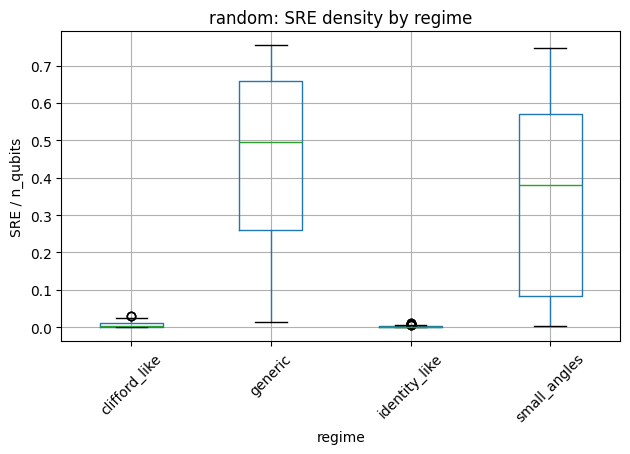

In [93]:
plot_SRE_regime(output_dir, "random")

In [94]:
train_loader_random, val_loader_random, test_loader_random, node_in_dim_random, global_in_dim_random, base_dataset_random = make_dataset_loaders(model_type, epochs, lr, loss_type, batch_size, training_mode, "random", target, output_dir, model_save_path, show_progress, show_val_progress, log_every_n_batches, heartbeat_secs, epoch_time_warning_secs)

2026-05-21 15:32:54,675 - __main__ - INFO - Found 675 data paths.
2026-05-21 15:32:54,676 - __main__ - INFO - Data paths collected.
2026-05-21 15:32:54,676 - __main__ - INFO - Building loaders and model for model_type=nn...


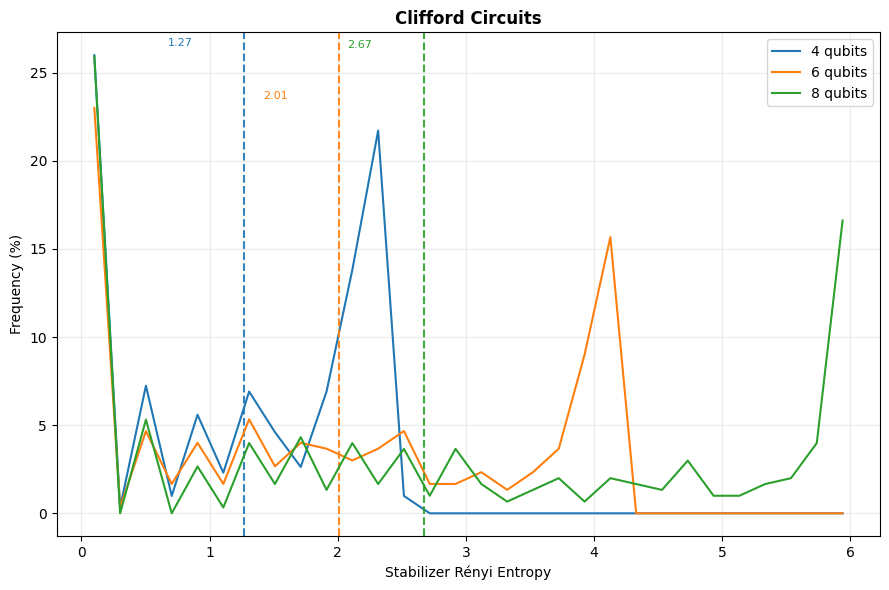

: 

In [ ]:
_plot_SRE_distribution(base_dataset_clifford, title="Clifford Circuits")

## Quansistor

In [37]:
quansistor_config = DataGenConfig(
    backend="pennylane",
    method="fwht",
    families=["quansistor"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    prediction_n_seeds = None,
    n_bins=50,
    compute_sre=True,
    compute_EE=False,
    target_qubits=(4,6,8),
    representation="dense",
    use_dask=True,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    output_dir=Path(output_dir),
    max_configs=None,
)

In [38]:
run_dataset_pipeline(
    config=quansistor_config,
    families=["quansistor"],
    qubits_values=np.array(n_qubits),
    layers_values=np.array(n_layers),
    n_seeds=n_seeds,
    use_dask=True,
    max_configs=None,
    dask_n_workers=4,
    dask_memory_per_worker="4GB",
    sampling_config=default_sampling_config(),
)

Parallel dataset generation: 100%|██████████| 900/900 [01:04<00:00, 13.95it/s]


<Figure size 640x480 with 0 Axes>

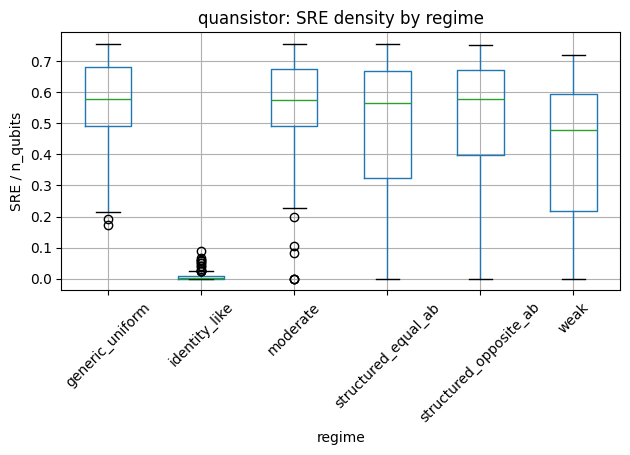

In [ ]:
plot_SRE_regime(output_dir, "quansistor")